### Cell 1: Imports and load data


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, roc_auc_score, 
                             RocCurveDisplay, confusion_matrix)
from sklearn.preprocessing import StandardScaler

# Load feature table
features = pd.read_csv("county_features.csv")
features["GEOID"] = features["GEOID"].astype(str).str.zfill(5)

print(f"Loaded {len(features)} counties")
print(f"Positive class (has_dc=1): {features['has_dc'].sum()} ({features['has_dc'].mean()*100:.1f}%)")

Loaded 3109 counties
Positive class (has_dc=1): 247 (7.9%)


### Cell 2: Define features and target


In [2]:
# Features used for modeling
# These are the variables Vabson et al. identify as siting-relevant
FEATURE_COLS = [
    "electricity_price",
    "renewable_mw_within_50km",
    "renewable_mw_in_county",
    "pop_density",
    "svi_score",
    "water_stress_score"
]

X = features[FEATURE_COLS].copy()
y = features["has_dc"].copy()

print("Feature matrix shape:", X.shape)
print("Class distribution:\n", y.value_counts())
print("\nAny missing values in features?", X.isna().sum().sum())

Feature matrix shape: (3109, 6)
Class distribution:
 has_dc
0    2862
1     247
Name: count, dtype: int64

Any missing values in features? 0


### Cell 3: Train/test split and train model


In [4]:
# 70/30 split, stratified to preserve class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.30, 
    random_state=42, 
    stratify=y
)

print(f"Train: {len(X_train)} counties ({y_train.sum()} positive)")
print(f"Test:  {len(X_test)} counties ({y_test.sum()} positive)")

# Random forest with class_weight='balanced' to handle the 8% positive class
rf = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print("\nModel trained.")

Train: 2176 counties (173 positive)
Test:  933 counties (74 positive)

Model trained.


### Cell 4: Evaluate on test set


In [5]:
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)
print(f"AUC-ROC: {auc:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No DC", "Has DC"]))

AUC-ROC: 0.893

Classification Report:
              precision    recall  f1-score   support

       No DC       0.94      0.99      0.96       859
      Has DC       0.68      0.23      0.34        74

    accuracy                           0.93       933
   macro avg       0.81      0.61      0.65       933
weighted avg       0.92      0.93      0.91       933



### Cell 5: Feature importances 


Feature Importances:
                 feature  importance
             pop_density    0.440061
renewable_mw_within_50km    0.140294
               svi_score    0.132565
  renewable_mw_in_county    0.104386
       electricity_price    0.095325
      water_stress_score    0.087369


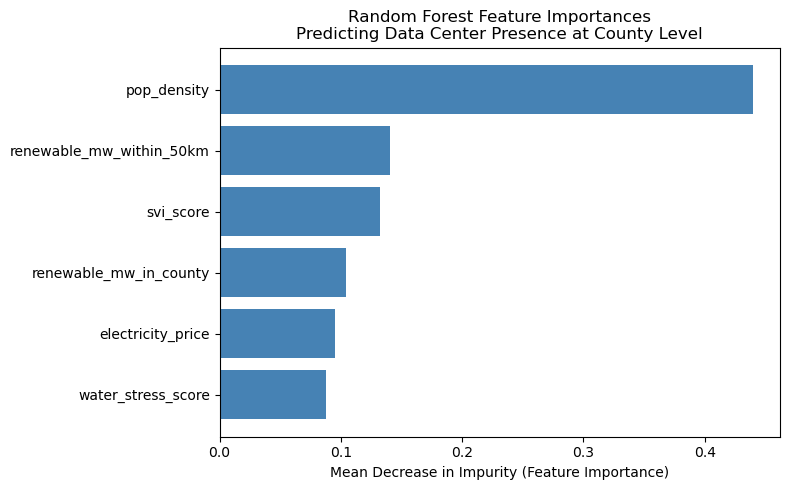

Saved: rf_feature_importances.png


In [6]:
importances = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

print("Feature Importances:")
print(importances.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importances["feature"], importances["importance"], color="steelblue")
ax.set_xlabel("Mean Decrease in Impurity (Feature Importance)")
ax.set_title("Random Forest Feature Importances\nPredicting Data Center Presence at County Level")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("rf_feature_importances.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: rf_feature_importances.png")

### Cell 6: Stability check across random seeds


In [7]:
# Run RF 50 times with different seeds, check if importances are stable
# This is the methodological check that justifies using RF-derived weights
stability_runs = []
for seed in range(50):
    rf_tmp = RandomForestClassifier(
        n_estimators=200, 
        class_weight="balanced", 
        random_state=seed,
        n_jobs=-1
    )
    rf_tmp.fit(X_train, y_train)
    stability_runs.append(rf_tmp.feature_importances_)

stability_df = pd.DataFrame(stability_runs, columns=FEATURE_COLS)
stability_summary = pd.DataFrame({
    "mean_importance": stability_df.mean(),
    "std_importance":  stability_df.std(),
    "cv":              stability_df.std() / stability_df.mean()  # coefficient of variation
}).sort_values("mean_importance", ascending=False)

print("Feature Importance Stability (50 random seeds):")
print(stability_summary.round(4).to_string())
print("\nLow CV (<0.15) = stable. High CV (>0.30) = treat with caution.")

Feature Importance Stability (50 random seeds):
                          mean_importance  std_importance      cv
pop_density                        0.4408          0.0052  0.0118
renewable_mw_within_50km           0.1406          0.0027  0.0191
svi_score                          0.1321          0.0017  0.0127
renewable_mw_in_county             0.1058          0.0023  0.0215
electricity_price                  0.0930          0.0021  0.0223
water_stress_score                 0.0877          0.0017  0.0195

Low CV (<0.15) = stable. High CV (>0.30) = treat with caution.


### Cell 7: Save predicted probabilities for use in MILP


In [8]:
# Predict probability of data center presence for ALL counties
# This becomes the suitability signal that feeds into the MILP
features["rf_suitability"] = rf.predict_proba(X)[:, 1]

# Save for MILP notebook
features.to_csv("county_features_with_rf.csv", index=False)
print("Saved county_features_with_rf.csv")
print(f"\nTop 15 counties by RF suitability score (currently NO data center):")
print(
    features[features["has_dc"] == 0]
    .nlargest(15, "rf_suitability")
    [["county_name", "state_name", "rf_suitability", 
      "electricity_price", "renewable_mw_within_50km", "water_stress_score"]]
    .to_string(index=False)
)

Saved county_features_with_rf.csv

Top 15 counties by RF suitability score (currently NO data center):
county_name    state_name  rf_suitability  electricity_price  renewable_mw_within_50km  water_stress_score
     Marion       Indiana           0.742               8.77                     119.5            2.000430
       Will      Illinois           0.710              10.10                      88.4            2.270556
 New Castle      Delaware           0.700              10.58                     205.5            3.361336
Northampton  Pennsylvania           0.612              10.40                     308.1            1.587865
       Kane      Illinois           0.610              10.10                     267.1            2.270556
      Bucks  Pennsylvania           0.526              10.40                     349.4            1.587865
 Montgomery          Ohio           0.520               9.33                      42.8            1.542806
   Delaware  Pennsylvania           0.504

#

# Section B: MILP

In [10]:
!pip install pulp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 36.5 MB/s eta 0:00:0031m40.9 MB/s eta 0:00:01


### Cell 8: Setup and prepare data for optimization

In [11]:
from pulp import (LpProblem, LpMinimize, LpVariable, LpBinary, 
                  lpSum, PULP_CBC_CMD, LpStatus)
from sklearn.preprocessing import StandardScaler

# Load features with RF suitability scores
df = pd.read_csv("county_features_with_rf.csv")
df["GEOID"] = df["GEOID"].astype(str).str.zfill(5)

# Only consider counties that do NOT currently have a data center
# We're optimizing where to site NEW facilities
candidates = df[df["has_dc"] == 0].copy().reset_index(drop=True)
print(f"Candidate counties (no existing data center): {len(candidates)}")

# Z-score all features so they're on the same scale
# This is critical — without it, pop_density (range 0-28000) would 
# dominate over svi_score (range 0-1) regardless of weights
FEATURE_COLS = [
    "electricity_price",
    "renewable_mw_within_50km",
    "renewable_mw_in_county",
    "pop_density",
    "svi_score",
    "water_stress_score"
]

scaler = StandardScaler()
candidates[FEATURE_COLS] = scaler.fit_transform(candidates[FEATURE_COLS])

print("Z-scored feature ranges:")
print(candidates[FEATURE_COLS].describe().loc[["mean", "std", "min", "max"]].round(2))

Candidate counties (no existing data center): 2862
Z-scored feature ranges:
      electricity_price  renewable_mw_within_50km  renewable_mw_in_county  \
mean              -0.00                      0.00                   -0.00   
std                1.00                      1.00                    1.00   
min               -1.27                     -0.68                   -0.34   
max                6.34                      7.19                   30.77   

      pop_density  svi_score  water_stress_score  
mean         0.00       0.00                0.00  
std          1.00       1.00                1.00  
min         -0.18      -1.71               -2.28  
max         36.53       1.73                2.80  


### Cell 9: Define the MILP objective function using RF-derived weights


In [26]:
# RF-derived feature importances from stability analysis
# Sign convention: positive = we want MORE of this, negative = we want LESS
# Updated weights — remove pop_density from objective
rf_weights = {
    "electricity_price":        -0.0930,
    "renewable_mw_within_50km":  0.1406,
    "renewable_mw_in_county":    0.1058,
    "pop_density":               0.0,     # removed from objective
    "svi_score":                -0.1321,
    "water_stress_score":       -0.0877,
}

# Add density as a constraint instead
# County must have at least minimal density (z-score > -0.8, roughly 5th percentile)
for i in counties_list:
    if candidates.loc[i, "pop_density"] < -0.8:
        prob += x[i] == 0

# The MILP MINIMIZES, so we negate the whole thing
# (maximizing benefit = minimizing negative benefit)
# Cost for each county = -1 * (sum of weight_i * z_scored_feature_i)
# Negative weights on price/svi/water already flip them

candidates["site_cost"] = 0
for feat, weight in rf_weights.items():
    candidates["site_cost"] += -weight * candidates[feat]
    # Note the negation: MILP minimizes, so we negate weights where "more is better"
    # and keep weights where "less is better"

print("Site cost distribution (lower = more attractive):")
print(candidates["site_cost"].describe().round(3))

Site cost distribution (lower = more attractive):
count    2862.000
mean       -0.000
std         0.268
min        -2.786
25%        -0.102
50%         0.032
75%         0.149
max         0.973
Name: site_cost, dtype: float64


### Cell 10: Build and solve the MILP


In [27]:
N_SELECT = 15  # number of counties to recommend

counties_list = candidates.index.tolist()

# Decision variables: binary x_i for each candidate county
x = {i: LpVariable(f"x_{i}", cat=LpBinary) for i in counties_list}

# Define the problem
prob = LpProblem("DataCenter_Siting", LpMinimize)

# Objective: minimize total site cost across selected counties
prob += lpSum(x[i] * candidates.loc[i, "site_cost"] for i in counties_list)

# Constraint 1: select exactly N counties
prob += lpSum(x[i] for i in counties_list) == N_SELECT

# Constraint 2: minimum renewable capacity within 50km
# (must have at least some nearby renewable infrastructure)
# Using z-score > -0.5 means roughly above the 30th percentile
for i in counties_list:
    if candidates.loc[i, "renewable_mw_within_50km"] < -0.5:
        prob += x[i] == 0

# Constraint 3: water stress cannot be extreme
# z-score > 1.5 means roughly the top 7% most stressed counties
for i in counties_list:
    if candidates.loc[i, "water_stress_score"] > 1.5:
        prob += x[i] == 0

# Constraint 4: SVI cannot be extreme
# z-score > 1.5 means the most vulnerable ~7% of counties
for i in counties_list:
    if candidates.loc[i, "svi_score"] > 1.5:
        prob += x[i] == 0

# Constraint 5: at most 3 counties per state (spatial diversity)
for state_fips in candidates["STATEFP"].unique():
    state_idx = candidates[candidates["STATEFP"] == state_fips].index.tolist()
    prob += lpSum(x[i] for i in state_idx) <= 3

# Solve
prob.solve(PULP_CBC_CMD(msg=0))
print(f"Solver status: {LpStatus[prob.status]}")
print(f"Optimal objective value: {prob.objective.value():.3f}")

Solver status: Optimal
Optimal objective value: -18.385


### Cell 11: Extract and display results


In [28]:
# Get selected counties
selected_idx = [i for i in counties_list if x[i].value() == 1]
print(f"\nSelected {len(selected_idx)} counties for recommended siting:\n")

# Reload unscaled data for readable output
df_raw = pd.read_csv("county_features_with_rf.csv")
df_raw["GEOID"] = df_raw["GEOID"].astype(str).str.zfill(5)
no_dc = df_raw[df_raw["has_dc"] == 0].reset_index(drop=True)

results = no_dc.loc[selected_idx, [
    "GEOID", "county_name", "state_name",
    "electricity_price", "renewable_mw_within_50km", 
    "pop_density", "svi_score", "water_stress_score",
    "rf_suitability"
]].copy()

results = results.sort_values("rf_suitability", ascending=False)

print(results.to_string(index=False))


Selected 15 counties for recommended siting:

GEOID county_name state_name  electricity_price  renewable_mw_within_50km  pop_density  svi_score  water_stress_score  rf_suitability
41021     Gilliam     Oregon               8.08                    2943.3     0.631687     0.5282            0.695814           0.142
41055     Sherman     Oregon               8.08                    2299.9     0.938517     0.3376            0.695814           0.102
53039   Klickitat Washington               6.92                    2895.2     4.976570     0.6414            0.739591           0.042
18181       White    Indiana               8.77                    2618.6    18.981163     0.2221            2.000430           0.030
48371       Pecos      Texas               6.67                    1610.5     1.192387     0.9049            2.702351           0.016
48415      Scurry      Texas               6.67                    3577.8     6.912740     0.5332            2.702351           0.010
40043       Dew

### Cell 12: Compare with current data center counties


In [29]:
# How do the MILP-selected counties compare to where data centers actually are?
existing_dc = df_raw[df_raw["has_dc"] == 1]

comparison = pd.DataFrame({
    "Metric": [
        "Avg electricity price (¢/kWh)",
        "Avg renewable MW within 50km",
        "Avg population density (per km²)",
        "Avg SVI score (0-1)",
        "Avg water stress (0-5)"
    ],
    "Current DC Counties": [
        existing_dc["electricity_price"].mean(),
        existing_dc["renewable_mw_within_50km"].mean(),
        existing_dc["pop_density"].mean(),
        existing_dc["svi_score"].mean(),
        existing_dc["water_stress_score"].mean()
    ],
    "MILP Recommended": [
        results["electricity_price"].mean(),
        results["renewable_mw_within_50km"].mean(),
        results["pop_density"].mean(),
        results["svi_score"].mean(),
        results["water_stress_score"].mean()
    ]
})

comparison["Current DC Counties"] = comparison["Current DC Counties"].round(2)
comparison["MILP Recommended"] = comparison["MILP Recommended"].round(2)

print("Comparison: Current Data Center Counties vs MILP Recommended Sites\n")
print(comparison.to_string(index=False))

Comparison: Current Data Center Counties vs MILP Recommended Sites

                          Metric  Current DC Counties  MILP Recommended
   Avg electricity price (¢/kWh)                 9.45              7.44
    Avg renewable MW within 50km               294.10           2423.69
Avg population density (per km²)               644.38              7.04
             Avg SVI score (0-1)                 0.51              0.34
          Avg water stress (0-5)                 2.15              1.71


### Cell 13: Sensitivity analysis (vary N and constraints)


In [30]:
# Test how results change with different numbers of sites
print(" SENSITIVITY: Varying number of sites \n")

for n in [5, 10, 15, 20, 25]:
    prob_s = LpProblem(f"Siting_N{n}", LpMinimize)
    x_s = {i: LpVariable(f"x_{n}_{i}", cat=LpBinary) for i in counties_list}
    
    prob_s += lpSum(x_s[i] * candidates.loc[i, "site_cost"] for i in counties_list)
    prob_s += lpSum(x_s[i] for i in counties_list) == n
    
    # Same constraints as before
    for i in counties_list:
        if candidates.loc[i, "renewable_mw_within_50km"] < -0.5:
            prob_s += x_s[i] == 0
        if candidates.loc[i, "water_stress_score"] > 1.5:
            prob_s += x_s[i] == 0
        if candidates.loc[i, "svi_score"] > 1.5:
            prob_s += x_s[i] == 0
    
    for state_fips in candidates["STATEFP"].unique():
        state_idx = candidates[candidates["STATEFP"] == state_fips].index.tolist()
        prob_s += lpSum(x_s[i] for i in state_idx) <= 3
    
    prob_s.solve(PULP_CBC_CMD(msg=0))
    
    sel = [i for i in counties_list if x_s[i].value() == 1]
    sel_data = no_dc.loc[sel]
    
    print(f"N={n:2d} | Avg price: ${sel_data['electricity_price'].mean():.1f} | "
          f"Avg renew 50km: {sel_data['renewable_mw_within_50km'].mean():.0f} MW | "
          f"Avg SVI: {sel_data['svi_score'].mean():.3f} | "
          f"Avg water: {sel_data['water_stress_score'].mean():.2f} | "
          f"States: {sel_data['state_name'].nunique()}")

print("\n SENSITIVITY: Equal weights vs RF weights \n")

# Rerun with equal weights for comparison
equal_weights = {feat: 1/6 for feat in FEATURE_COLS}
equal_weights["electricity_price"] *= -1
equal_weights["svi_score"] *= -1
equal_weights["water_stress_score"] *= -1

candidates["equal_cost"] = 0
for feat, weight in equal_weights.items():
    candidates["equal_cost"] += -weight * candidates[feat]

prob_eq = LpProblem("Siting_EqualWeights", LpMinimize)
x_eq = {i: LpVariable(f"x_eq_{i}", cat=LpBinary) for i in counties_list}
prob_eq += lpSum(x_eq[i] * candidates.loc[i, "equal_cost"] for i in counties_list)
prob_eq += lpSum(x_eq[i] for i in counties_list) == 15

for i in counties_list:
    if candidates.loc[i, "renewable_mw_within_50km"] < -0.5:
        prob_eq += x_eq[i] == 0
    if candidates.loc[i, "water_stress_score"] > 1.5:
        prob_eq += x_eq[i] == 0
    if candidates.loc[i, "svi_score"] > 1.5:
        prob_eq += x_eq[i] == 0

for state_fips in candidates["STATEFP"].unique():
    state_idx = candidates[candidates["STATEFP"] == state_fips].index.tolist()
    prob_eq += lpSum(x_eq[i] for i in state_idx) <= 3

prob_eq.solve(PULP_CBC_CMD(msg=0))

sel_eq = [i for i in counties_list if x_eq[i].value() == 1]
sel_rf = [i for i in counties_list if x[i].value() == 1]

overlap = set(sel_eq) & set(sel_rf)
print(f"RF-weighted selected: {len(sel_rf)} counties")
print(f"Equal-weighted selected: {len(sel_eq)} counties")
print(f"Overlap: {len(overlap)} counties appear in both")
print(f"\nCounties unique to RF weighting:")
rf_only = no_dc.loc[list(set(sel_rf) - set(sel_eq)), ["county_name", "state_name"]]
print(rf_only.to_string(index=False))
print(f"\nCounties unique to equal weighting:")
eq_only = no_dc.loc[list(set(sel_eq) - set(sel_rf)), ["county_name", "state_name"]]
print(eq_only.to_string(index=False))

 SENSITIVITY: Varying number of sites 

N= 5 | Avg price: $7.4 | Avg renew 50km: 2966 MW | Avg SVI: 0.390 | Avg water: 1.77 | States: 4
N=10 | Avg price: $7.6 | Avg renew 50km: 2585 MW | Avg SVI: 0.393 | Avg water: 1.81 | States: 6
N=15 | Avg price: $7.4 | Avg renew 50km: 2424 MW | Avg SVI: 0.342 | Avg water: 1.71 | States: 8
N=20 | Avg price: $7.5 | Avg renew 50km: 2271 MW | Avg SVI: 0.364 | Avg water: 1.70 | States: 11
N=25 | Avg price: $7.7 | Avg renew 50km: 2103 MW | Avg SVI: 0.335 | Avg water: 1.67 | States: 13

 SENSITIVITY: Equal weights vs RF weights 

RF-weighted selected: 15 counties
Equal-weighted selected: 15 counties
Overlap: 11 counties appear in both

Counties unique to RF weighting:
county_name state_name
      Adair       Iowa
       Ford     Kansas
       Cass       Iowa
     Jasper    Indiana

Counties unique to equal weighting:
county_name    state_name
 Alexandria      Virginia
    Suffolk Massachusetts
  Arlington      Virginia
     Queens      New York


### Cell 14: Save results for mapping


In [31]:
# Tag all candidates with whether they were selected by MILP
candidates_out = no_dc.copy()
candidates_out["milp_selected"] = 0
candidates_out.loc[selected_idx, "milp_selected"] = 1

# Also add the site_cost (on raw scale for interpretability)
# Re-merge rf_suitability 
candidates_out.to_csv("milp_results.csv", index=False)
print(f"Saved milp_results.csv")
print(f"MILP selected counties: {candidates_out['milp_selected'].sum()}")

Saved milp_results.csv
MILP selected counties: 15


### Cell 15: Setup for mapping

In [32]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings("ignore")

# Load county shapefile again (same as county_features notebook)
COUNTIES_URL = "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_county_20m.zip"
counties_geo = gpd.read_file(COUNTIES_URL)

# Drop territories, keep continental US
EXCLUDE = {"02", "15", "60", "66", "69", "72", "78"}
counties_geo = counties_geo[~counties_geo["STATEFP"].isin(EXCLUDE)].copy()
counties_geo["GEOID"] = counties_geo["GEOID"].astype(str).str.zfill(5)
counties_geo = counties_geo.to_crs("EPSG:5070")

# Load your results
df_rf = pd.read_csv("county_features_with_rf.csv")
df_rf["GEOID"] = df_rf["GEOID"].astype(str).str.zfill(5)

df_milp = pd.read_csv("milp_results.csv")
df_milp["GEOID"] = df_milp["GEOID"].astype(str).str.zfill(5)

# Merge rf suitability onto geo
geo = counties_geo.merge(df_rf[["GEOID", "rf_suitability", "has_dc", 
                                  "svi_score", "renewable_mw_within_50km",
                                  "water_stress_score", "pop_density"]], 
                          on="GEOID", how="left")

# Add MILP selected flag
geo = geo.merge(df_milp[["GEOID", "milp_selected"]], on="GEOID", how="left")
geo["milp_selected"] = geo["milp_selected"].fillna(0)

print(f"Geo shape: {geo.shape}")
print(f"MILP selected in geo: {geo['milp_selected'].sum()}")
print(f"Has DC in geo: {geo['has_dc'].sum()}")

Geo shape: (3109, 20)
MILP selected in geo: 15.0
Has DC in geo: 247


### Cell 16: Map 1 - RF Suitability Scores (all counties)

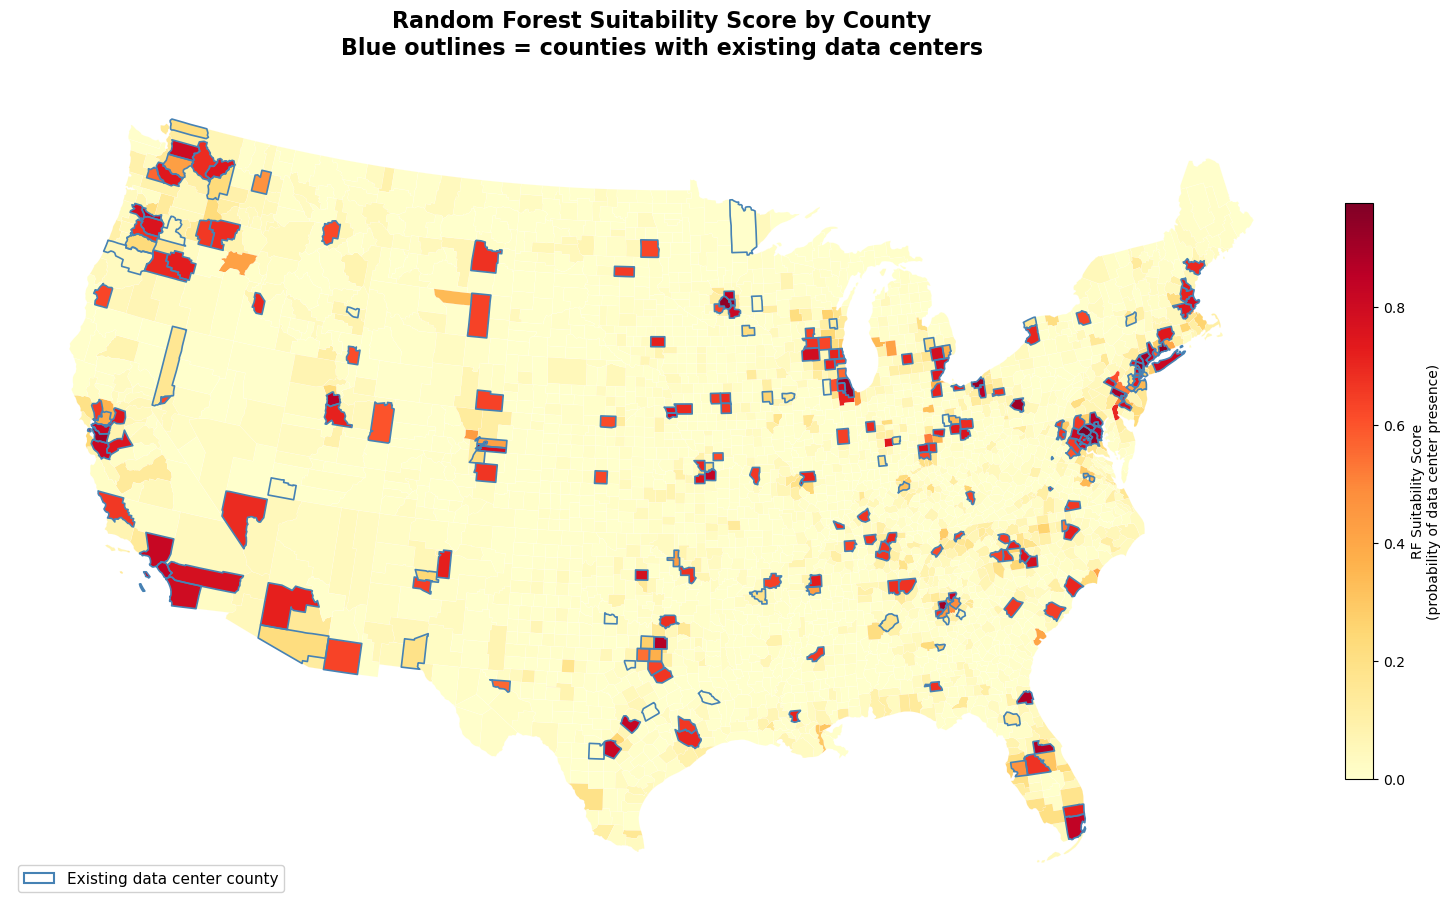

Saved: map1_rf_suitability.png


In [33]:
fig, ax = plt.subplots(1, 1, figsize=(16, 10))

# Base layer: all counties colored by RF suitability
geo.plot(
    column="rf_suitability",
    ax=ax,
    cmap="YlOrRd",
    legend=True,
    legend_kwds={
        "label": "RF Suitability Score\n(probability of data center presence)",
        "orientation": "vertical",
        "shrink": 0.6,
        "pad": 0.02
    },
    missing_kwds={"color": "lightgrey", "label": "No data"},
    linewidth=0.1,
    edgecolor="white"
)

# Overlay: existing data center counties with blue outline
geo[geo["has_dc"] == 1].plot(
    ax=ax,
    facecolor="none",
    edgecolor="steelblue",
    linewidth=1.2,
    label="Current data center county"
)

# Styling
ax.set_axis_off()
ax.set_title(
    "Random Forest Suitability Score by County\n"
    "Blue outlines = counties with existing data centers",
    fontsize=16, fontweight="bold", pad=20
)

# Legend patch for blue outline
blue_patch = mpatches.Patch(
    facecolor="none", edgecolor="steelblue", linewidth=1.5,
    label="Existing data center county"
)
ax.legend(handles=[blue_patch], loc="lower left", fontsize=11,
          framealpha=0.9)

plt.tight_layout()
plt.savefig("map1_rf_suitability.png", dpi=200, bbox_inches="tight",
            facecolor="white")
plt.show()
print("Saved: map1_rf_suitability.png")

### Cell 17: Map 2 - MILP Selected Counties with Equity Overlay


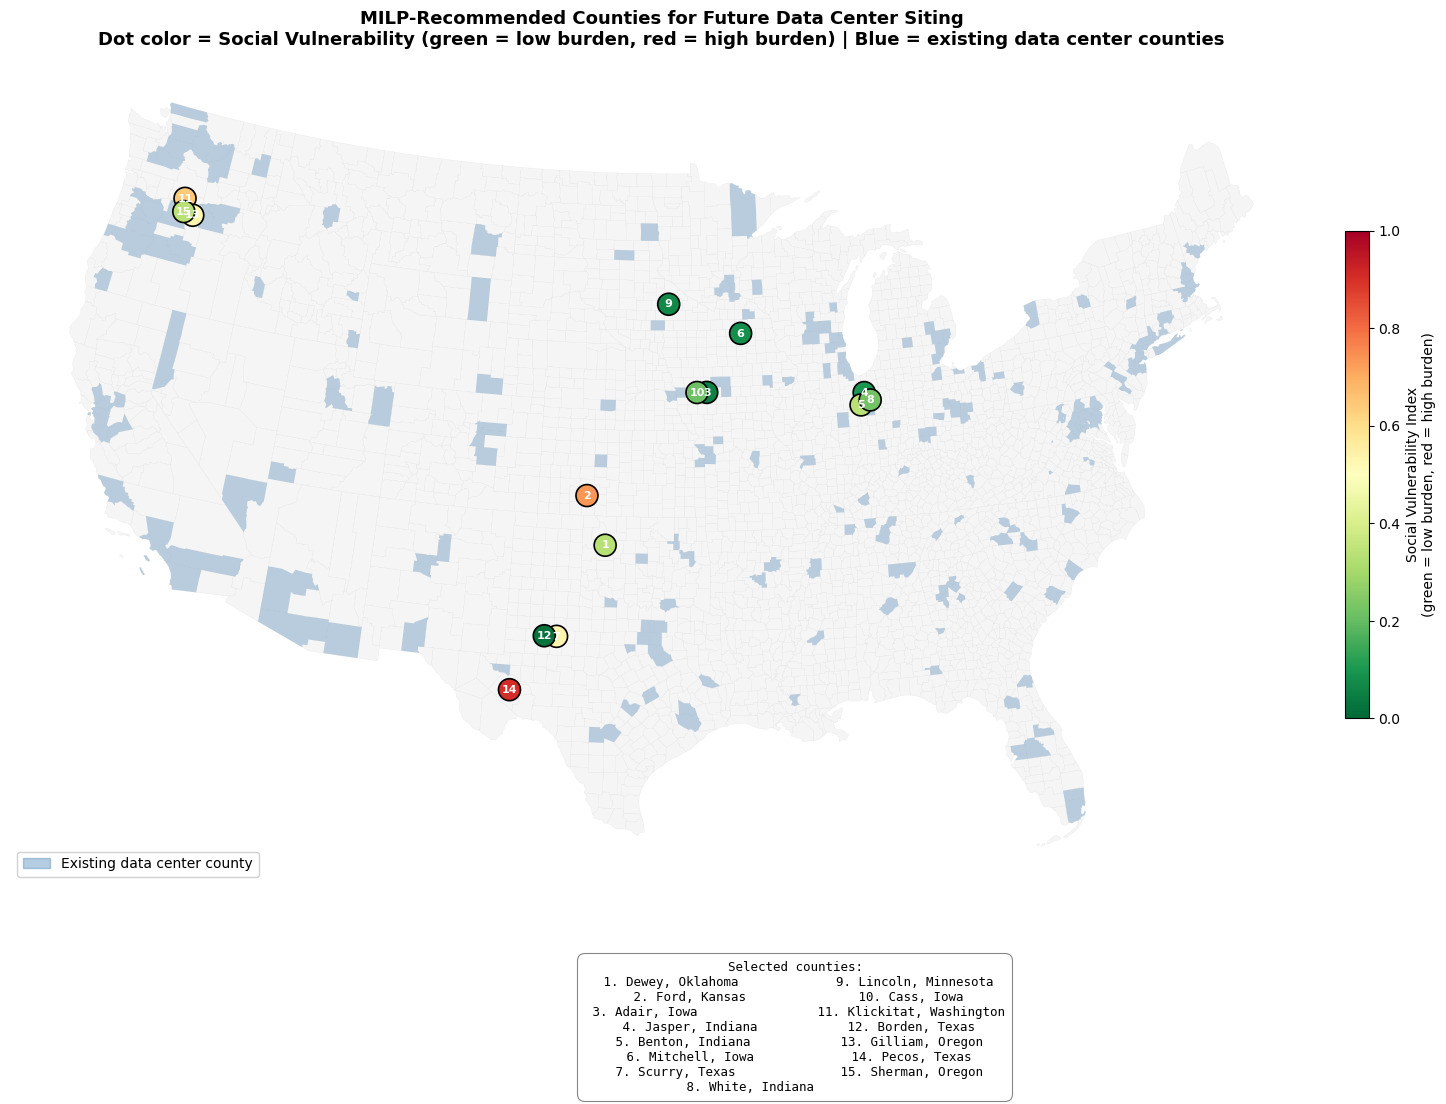

Saved: map2_milp_selected.png


In [41]:
fig, ax = plt.subplots(1, 1, figsize=(16, 11))

# Base: all counties light grey
geo.plot(
    ax=ax,
    color="whitesmoke",
    edgecolor="lightgrey",
    linewidth=0.1
)

# Layer: existing data center counties (light blue fill)
geo[geo["has_dc"] == 1].plot(
    ax=ax,
    color="steelblue",
    alpha=0.35,
    edgecolor="none",
    linewidth=0
)

# Layer: MILP selected counties — plot as CENTROIDS
milp_geo = geo[geo["milp_selected"] == 1].copy()
milp_geo["centroid"] = milp_geo.geometry.centroid
milp_centroids = milp_geo.set_geometry("centroid")

# Color centroids by SVI score
scatter = milp_centroids.plot(
    column="svi_score",
    ax=ax,
    cmap="RdYlGn_r",
    vmin=0,
    vmax=1,
    markersize=250,
    edgecolor="black",
    linewidth=1.2,
    legend=True,
    legend_kwds={
        "label": "Social Vulnerability Index\n(green = low burden, red = high burden)",
        "orientation": "vertical",
        "shrink": 0.55,
        "pad": 0.02
    },
    zorder=5
)

# Reset index for clean 1-15 numbering
milp_geo_reset = milp_geo.reset_index(drop=True)

# Detect which column has the county name (geopandas shapefile usually has 'NAME')
name_col = None
for candidate in ["county_name", "NAME", "NAMELSAD"]:
    if candidate in milp_geo_reset.columns:
        name_col = candidate
        break

if name_col is None:
    # Fall back: use GEOID
    name_col = "GEOID"

# Detect state column similarly
state_col = None
for candidate in ["state_name", "STATE_NAME", "STATEFP"]:
    if candidate in milp_geo_reset.columns:
        state_col = candidate
        break

# Add numbers directly on each dot
for idx, row in milp_geo_reset.iterrows():
    cx = row["centroid"].x
    cy = row["centroid"].y
    ax.annotate(
        str(idx + 1),
        xy=(cx, cy),
        fontsize=8,
        ha="center",
        va="center",
        color="white",
        fontweight="bold",
        zorder=6
    )

# Build legend string: "1. County, State"
legend_entries = []
for idx, row in milp_geo_reset.iterrows():
    county = row[name_col] if pd.notna(row[name_col]) else "Unknown"
    state = row[state_col] if state_col and pd.notna(row[state_col]) else ""
    legend_entries.append(f"{idx+1:>2}. {county}, {state}")

# Split into two columns for compactness
half = (len(legend_entries) + 1) // 2
col1 = legend_entries[:half]
col2 = legend_entries[half:]
# Pad col2 so both columns align
while len(col2) < len(col1):
    col2.append("")

legend_str = "Selected counties:\n" + "\n".join(
    f"{a:<30} {b}" for a, b in zip(col1, col2)
)

ax.set_axis_off()
ax.set_title(
    "MILP-Recommended Counties for Future Data Center Siting\n"
    "Dot color = Social Vulnerability (green = low burden, red = high burden) | "
    "Blue = existing data center counties",
    fontsize=13, fontweight="bold", pad=15
)

# Place legend text ABOVE the map using figure-level text
fig.text(
    0.5, 0.02,
    legend_str,
    fontsize=9,
    ha="center",
    va="bottom",
    fontfamily="monospace",
    bbox=dict(
        boxstyle="round,pad=0.6",
        facecolor="white",
        edgecolor="grey",
        linewidth=0.8,
        alpha=0.95
    )
)

# Existing data center legend patch inside the map
blue_patch = mpatches.Patch(color="steelblue", alpha=0.4,
                             label="Existing data center county")
ax.legend(handles=[blue_patch], loc="lower left", fontsize=10, framealpha=0.9)

plt.tight_layout()
# Make room at the bottom for the legend text
plt.subplots_adjust(bottom=0.18)
plt.savefig("map2_milp_selected.png", dpi=200, bbox_inches="tight",
            facecolor="white")
plt.show()
print("Saved: map2_milp_selected.png")

### Cell 18: Map 3 — Renewable Capacity vs Current Data Centers (mismatch map)

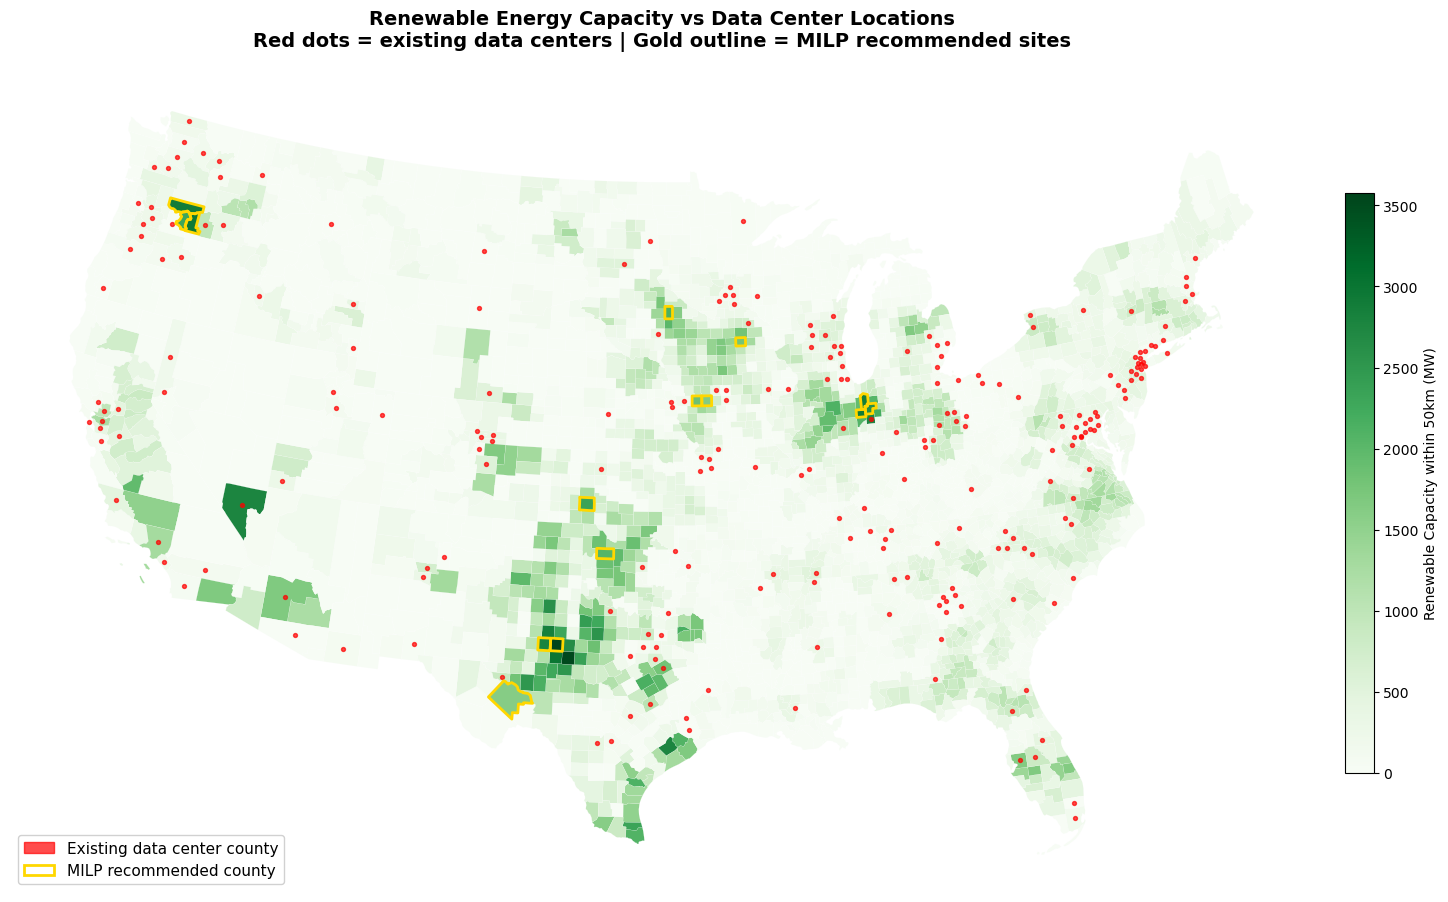

Saved: map3_renewable_mismatch.png


In [35]:
fig, ax = plt.subplots(1, 1, figsize=(16, 10))

# Base: renewable capacity within 50km choropleth
geo.plot(
    column="renewable_mw_within_50km",
    ax=ax,
    cmap="Greens",
    legend=True,
    legend_kwds={
        "label": "Renewable Capacity within 50km (MW)",
        "orientation": "vertical",
        "shrink": 0.6,
        "pad": 0.02
    },
    missing_kwds={"color": "lightgrey"},
    linewidth=0.1,
    edgecolor="white"
)

# Overlay: existing data centers as red dots
# Use county centroids
dc_geo = geo[geo["has_dc"] == 1].copy()
dc_geo["centroid"] = dc_geo.geometry.centroid
dc_centroids = dc_geo.copy()
dc_centroids = dc_centroids.set_geometry("centroid")

dc_centroids.plot(
    ax=ax,
    color="red",
    markersize=8,
    alpha=0.7,
    label="Existing data center county"
)

# Overlay: MILP selected counties with black outline
geo[geo["milp_selected"] == 1].plot(
    ax=ax,
    facecolor="none",
    edgecolor="gold",
    linewidth=2.0,
    label="MILP recommended county"
)

ax.set_axis_off()
ax.set_title(
    "Renewable Energy Capacity vs Data Center Locations\n"
    "Red dots = existing data centers | Gold outline = MILP recommended sites",
    fontsize=14, fontweight="bold", pad=20
)

red_patch = mpatches.Patch(color="red", alpha=0.7,
                            label="Existing data center county")
gold_patch = mpatches.Patch(facecolor="none", edgecolor="gold",
                             linewidth=2, label="MILP recommended county")
ax.legend(handles=[red_patch, gold_patch], loc="lower left",
          fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.savefig("map3_renewable_mismatch.png", dpi=200, bbox_inches="tight",
            facecolor="white")
plt.show()
print("Saved: map3_renewable_mismatch.png")

### Cell 19: Bar chart — Feature comparison current vs recommended


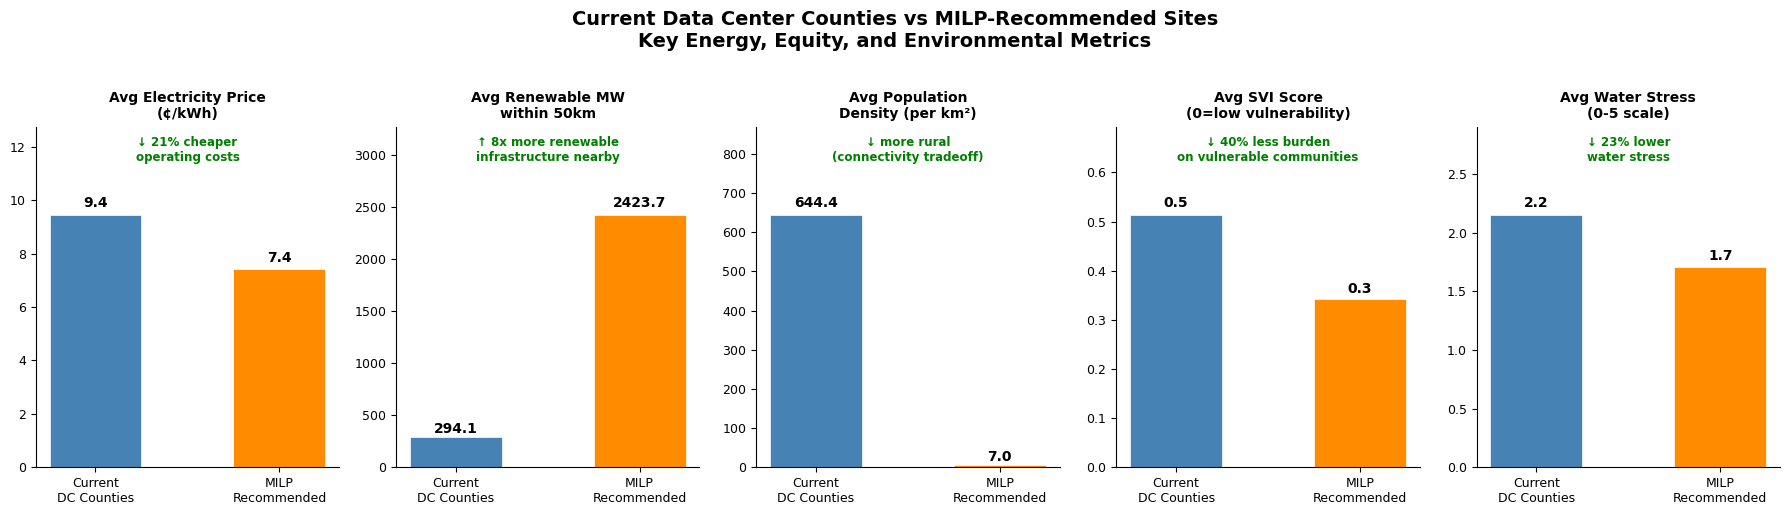

Saved: map4_comparison_bars.png


In [37]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

metrics = [
    (
        "electricity_price",
        "Avg Electricity Price\n(¢/kWh)",
        False,
        "↓ 21% cheaper\noperating costs"
    ),
    (
        "renewable_mw_within_50km",
        "Avg Renewable MW\nwithin 50km",
        True,
        "↑ 8x more renewable\ninfrastructure nearby"
    ),
    (
        "pop_density",
        "Avg Population\nDensity (per km²)",
        False,
        "↓ more rural\n(connectivity tradeoff)"
    ),
    (
        "svi_score",
        "Avg SVI Score\n(0=low vulnerability)",
        False,
        "↓ 40% less burden\non vulnerable communities"
    ),
    (
        "water_stress_score",
        "Avg Water Stress\n(0-5 scale)",
        False,
        "↓ 23% lower\nwater stress"
    ),
]

current = df_rf[df_rf["has_dc"] == 1]
recommended = df_rf[df_rf["GEOID"].isin(
    df_milp[df_milp["milp_selected"] == 1]["GEOID"]
)]

for ax, (col, label, higher_is_better, annotation) in zip(axes, metrics):
    val_current = current[col].mean()
    val_recommended = recommended[col].mean()

    bars = ax.bar(
        ["Current\nDC Counties", "MILP\nRecommended"],
        [val_current, val_recommended],
        color=["steelblue", "darkorange"],
        edgecolor="white",
        linewidth=0.5,
        width=0.5
    )

    for bar, val in zip(bars, [val_current, val_recommended]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + bar.get_height() * 0.02,
            f"{val:.1f}",
            ha="center", va="bottom", fontsize=10, fontweight="bold"
        )

    # Determine if recommended is actually better
    if higher_is_better:
        is_better = val_recommended > val_current
    else:
        is_better = val_recommended < val_current

    color = "green" if is_better else "#cc6600"  # orange-brown for tradeoff

    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.set_ylim(0, max(val_current, val_recommended) * 1.35)
    ax.tick_params(axis="x", labelsize=9)
    ax.tick_params(axis="y", labelsize=9)
    ax.spines[["top", "right"]].set_visible(False)

    ax.text(0.5, 0.90, annotation,
            transform=ax.transAxes,
            ha="center", fontsize=8.5,
            color=color, fontweight="bold",
            multialignment="center")

fig.suptitle(
    "Current Data Center Counties vs MILP-Recommended Sites\n"
    "Key Energy, Equity, and Environmental Metrics",
    fontsize=14, fontweight="bold", y=1.02
)

plt.tight_layout()
plt.savefig("map4_comparison_bars.png", dpi=200, bbox_inches="tight",
            facecolor="white")
plt.show()
print("Saved: map4_comparison_bars.png")